# MetaMask — Analyse des distributions de gas

Analyse des transactions MetaMask (EIP-7702, `0x63c0c19a282a1b52b07dd5a65b58948a07dae32b`) depuis `gas.db`.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 120

DB_PATH = Path('..') / 'gas.db'

con = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("""
    SELECT
        hash, block,
        max_fee_gwei,
        max_priority_gwei,
        base_fee_gwei,
        fee_factor,
        fee_factor_parent,
        gas_limit,
        estimated_gas,
        gas_limit_factor
    FROM transactions
    WHERE wallet = 'MetaMask'
      AND tx_type = 2
      AND max_priority_gwei IS NOT NULL
""", con)
con.close()

print(f"Transactions chargées : {len(df):,}")
print(f"Blocs couverts        : {df.block.min():,} → {df.block.max():,}")
df.describe().round(4)

Transactions chargées : 266,450
Blocs couverts        : 24,000,000 → 24,324,977


,block,max_fee_gwei,max_priority_gwei,base_fee_gwei,fee_factor,fee_factor_parent,gas_limit,estimated_gas,gas_limit_factor
count,2.664500e+05,266450.0000,266450.0000,266450.0000,266450.0000,266450.0000,2.664500e+05,2.257070e+05,225707.0000
mean,2.415626e+07,2.2685,0.9600,0.0564,28.8756,28.8004,5.058689e+05,3.009941e+05,3.1720
std,1.190595e+05,13.6826,3.3613,0.0510,297.4277,295.1247,1.425018e+06,1.040450e+06,13.6905
min,2.400000e+07,0.0207,0.0000,0.0196,0.0000,0.0000,2.100000e+04,2.100000e+04,0.1334
25%,2.402473e+07,0.0825,0.0020,0.0337,1.0800,1.1019,8.000000e+04,4.649100e+04,1.0000
50%,2.412504e+07,0.3528,0.1000,0.0410,1.3658,1.3747,1.302580e+05,1.190620e+05,1.4837
75%,2.430371e+07,2.0602,2.0000,0.0556,1.6398,1.5980,3.665408e+05,2.695485e+05,1.5000
max,2.432498e+07,1572.5095,777.0000,1.0551,37034.7022,35560.2250,1.677722e+07,1.677722e+07,706.8803


## 1. Top 10 — Priority fee (`maxPriorityFeePerGas`)

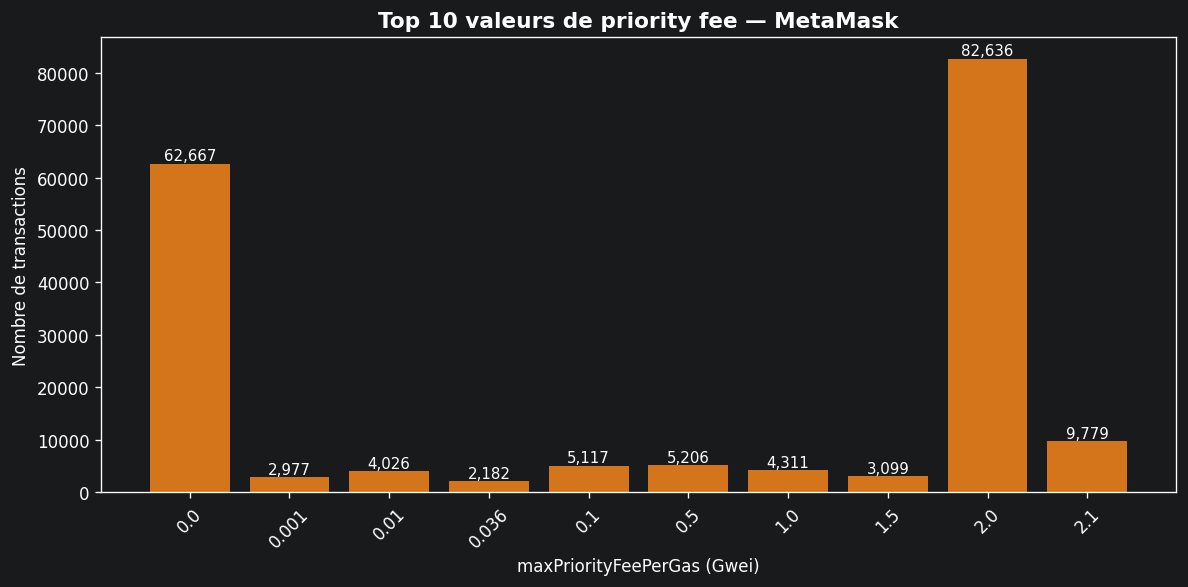


Top 10 valeurs de priority fee (arrondi à 2dp) :
max_priority_gwei
2.00    82663
0.00    69353
0.04    13091
0.03    10173
0.01     9907
2.10     9798
0.10     7017
0.05     7012
0.02     6884
0.50     5281


In [3]:
prio = df['max_priority_gwei'].dropna()

top_prio = prio.round(3).value_counts().head(10).sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top_prio.index.astype(str), top_prio.values, color='#F6851B', alpha=0.85)
ax.set_title('Top 10 valeurs de priority fee — MetaMask', fontsize=13, fontweight='bold')
ax.set_xlabel('maxPriorityFeePerGas (Gwei)')
ax.set_ylabel('Nombre de transactions')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top_prio.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 10 valeurs de priority fee (arrondi à 2dp) :")
print(prio.round(2).value_counts().head(10).to_string())

## 2. Top 10 — Fee factor parent (`fee_factor_parent`)

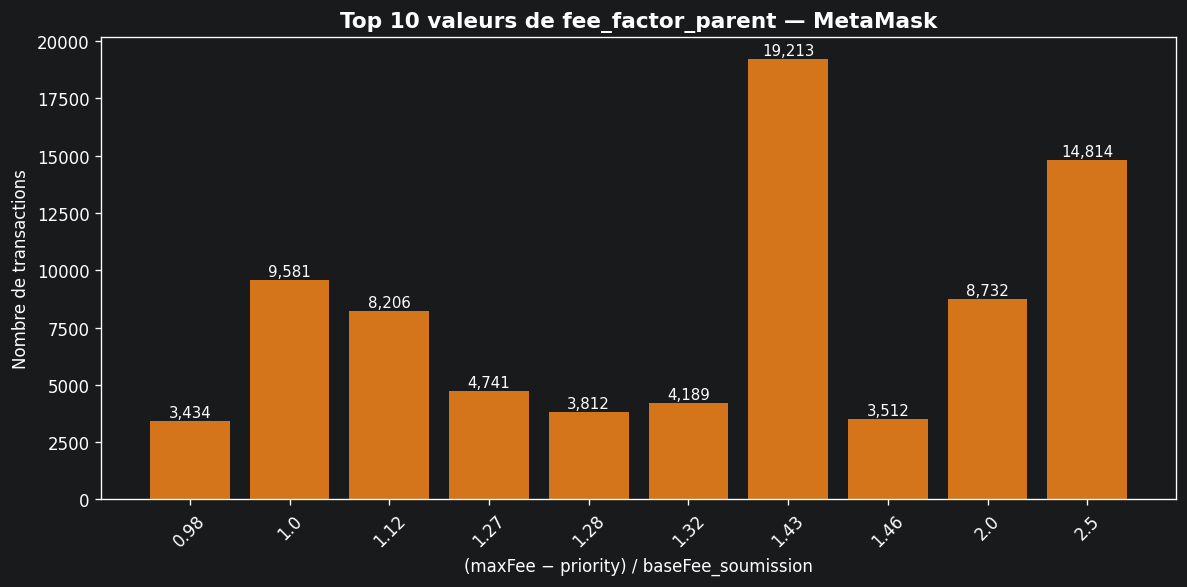


Top 10 valeurs de fee_factor_parent (arrondi à 2dp) :
fee_factor_parent
1.43    19213
2.50    14814
1.00     9581
2.00     8732
1.12     8206
1.27     4741
1.32     4189
1.28     3812
1.46     3512
0.98     3434


In [4]:
ff_parent = df['fee_factor_parent'].dropna()
ff_parent_zoom = ff_parent[(ff_parent > 0.5) & (ff_parent <= 4.0)]

top_ffp = ff_parent_zoom.round(2).value_counts().head(10).sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top_ffp.index.astype(str), top_ffp.values, color='#F6851B', alpha=0.85)
ax.set_title('Top 10 valeurs de fee_factor_parent — MetaMask', fontsize=13, fontweight='bold')
ax.set_xlabel('(maxFee − priority) / baseFee_soumission')
ax.set_ylabel('Nombre de transactions')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top_ffp.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 10 valeurs de fee_factor_parent (arrondi à 2dp) :")
print(ff_parent_zoom.round(2).value_counts().head(10).to_string())

## 3. Top 15 — Gas limit factor (`gasLimit / estimatedGas`)

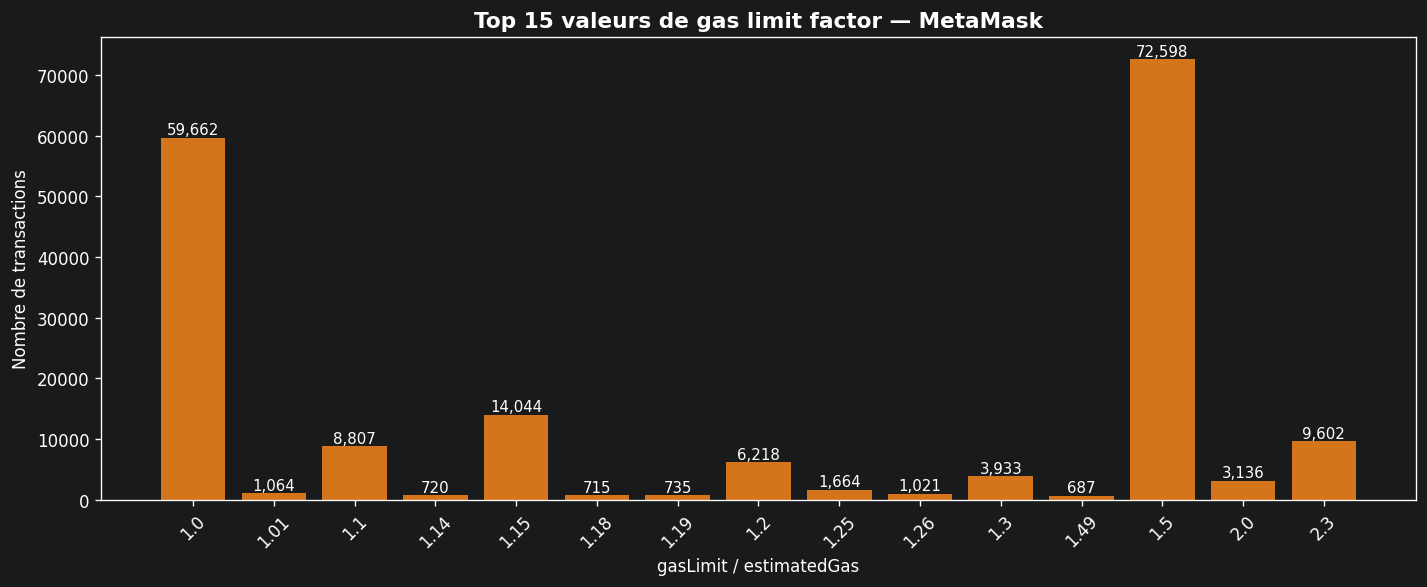


Top 15 valeurs de gas limit factor (arrondi à 2dp) :
gas_limit_factor
1.50    72598
1.00    59662
1.15    14044
2.30     9602
1.10     8807
1.20     6218
1.30     3933
2.00     3136
1.25     1664
1.01     1064
1.26     1021
1.19      735
1.14      720
1.18      715
1.49      687


In [5]:
glf = df['gas_limit_factor'].dropna()
glf_zoom = glf[(glf > 0.5) & (glf <= 5.0)]

top_glf = glf_zoom.round(2).value_counts().head(15).sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_glf.index.astype(str), top_glf.values, color='#F6851B', alpha=0.85)
ax.set_title('Top 15 valeurs de gas limit factor — MetaMask', fontsize=13, fontweight='bold')
ax.set_xlabel('gasLimit / estimatedGas')
ax.set_ylabel('Nombre de transactions')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top_glf.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 15 valeurs de gas limit factor (arrondi à 2dp) :")
print(glf_zoom.round(2).value_counts().head(15).to_string())